# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_3598/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_3598/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


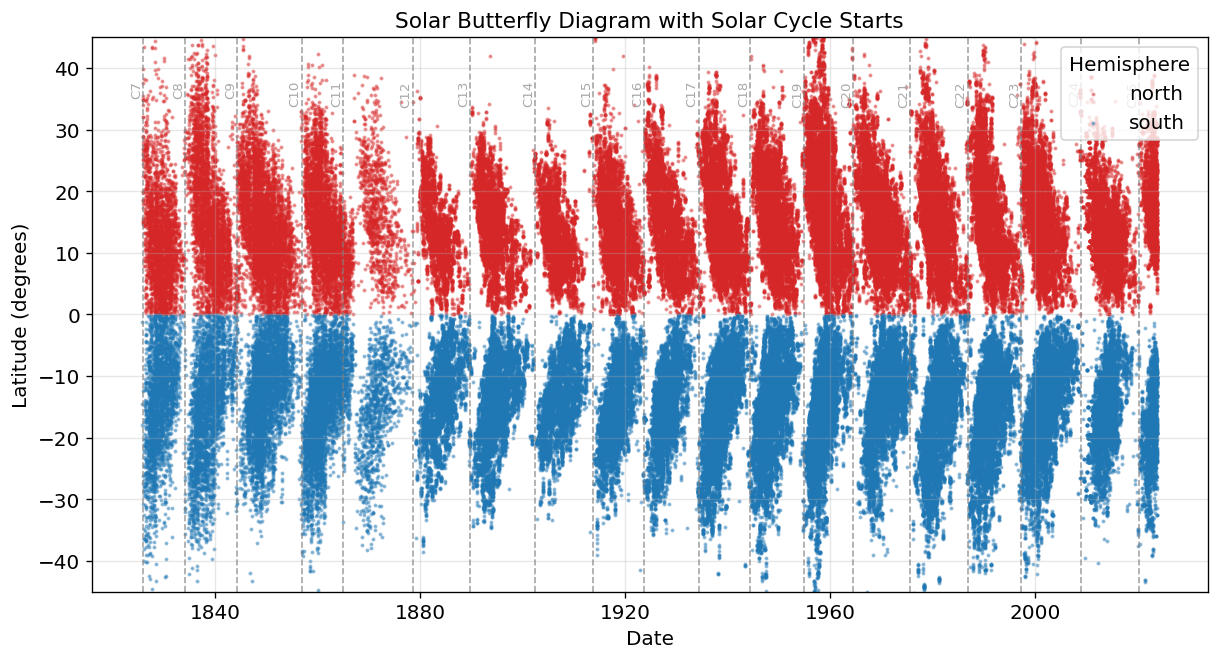

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(12, 6)) # Increased figure width for better readability
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

# Add solar cycle information
# Find the start date for each cycle
cycle_starts = df.dropna(subset=['CYCLE']).groupby('CYCLE')['date'].min()

# Plot vertical lines for each cycle start
for cycle_num, start_date in cycle_starts.items():
    ax.axvline(start_date, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    # Add a text label for the cycle number slightly below the top of the plot
    ax.text(start_date, 38, f'C{int(cycle_num)}', rotation=90, va='top', ha='right', color='darkgray', fontsize=8)

ax.set_title("Solar Butterfly Diagram with Solar Cycle Starts")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


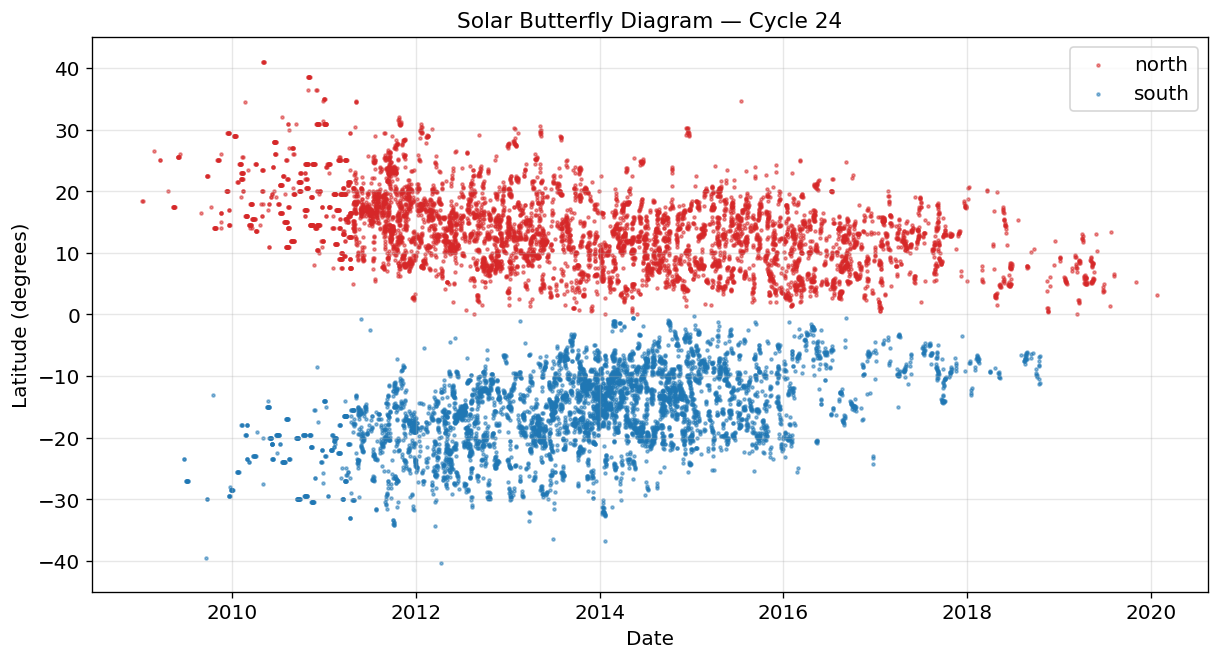

In [4]:
# Your code here: Visualize a single solar cycle
cycle_num = 24

df_c = df[df["CYCLE"] == cycle_num].copy()

fig, ax = plt.subplots(figsize=(12,6))
for hemi, g in df_c.groupby("hemisphere"):
    ax.scatter(g["date"], g["latitude"], s=3, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_num}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45,45)
ax.legend()
plt.show()

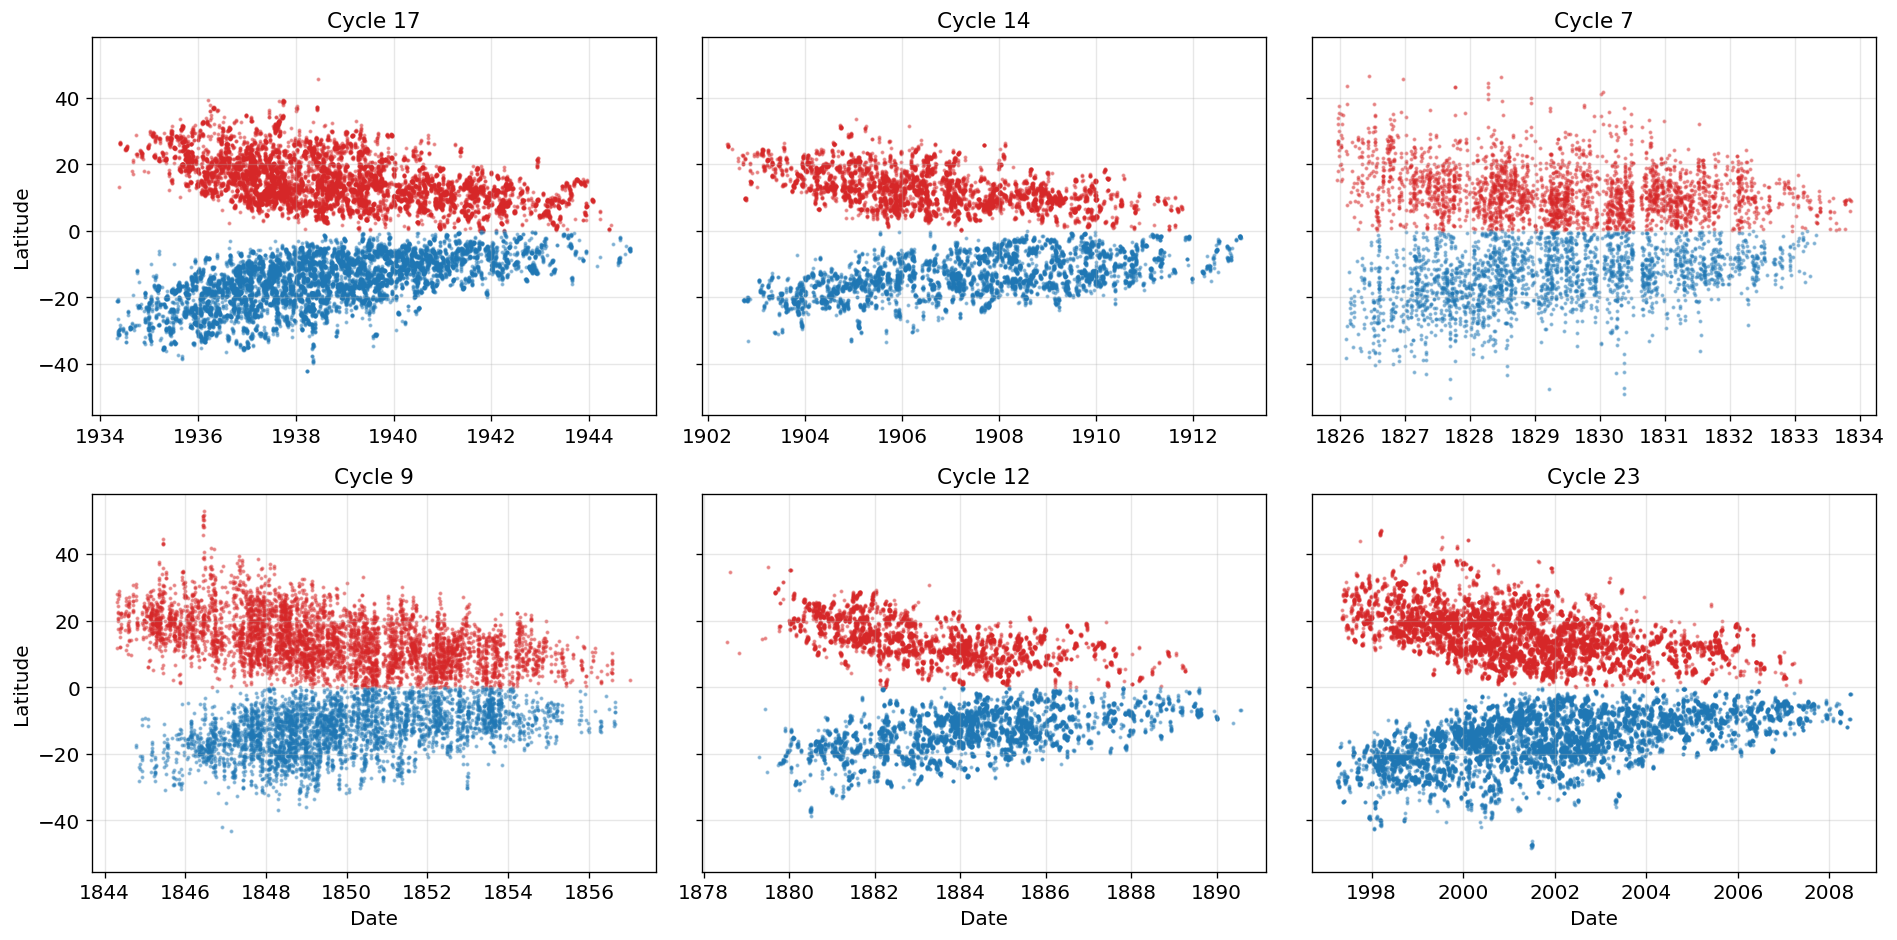

In [11]:
import numpy as np

cycles = sorted(df["CYCLE"].dropna().unique())
sample_cycles = np.random.choice(cycles, 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=True)

for ax, c in zip(axes.flatten(), sample_cycles):
    cyc = df[df["CYCLE"] == c]
    for hemi, g in cyc.groupby("hemisphere"):
        ax.scatter(g["date"], g["latitude"], s=2, c=colors[hemi], alpha=0.4)
    ax.set_title(f"Cycle {int(c)}")

for ax in axes[-1]:
    ax.set_xlabel("Date")
for ax in axes[:,0]:
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()



*   Cycles 17 and 23 look the most structured cohesively and the strongest in terms of intensity and duration. The points are concentrated densely, and we can clearly see the latitude initially wide apart and coming together.
*   Cycles 12 and 14 are still quite clear. Not as defined as the first two as aformentioned, but still has a clear structure, although the latitudinal spread is less well defined (lower density and lower amplitudes)
*  Cycles 7 and 9 look much more diffused/noisy- the wings are less sharply defined, with broader vertical scatter and less obvious structure. This could be due to phyiscal differences, but there is likely an influence of the fact that this data is much older, and we likely did not have the coverage and quality of observations that we do in some of these more recent cycles such as 23. It is quite interesting to see how with time, our observations have improved significantly.
* Overall, all of the cycles retain the charectaristic pattern (the butterfly wings), but there ar differences in amplitudes and coherences. Stronger cycles such as 17 and 23 have a denser set of points, with an initial wider spread of latitudes that comes together towards the end of the cycle. On the other hand, weaker cycles such as 12 and 14 are a little bit more compact overall.


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


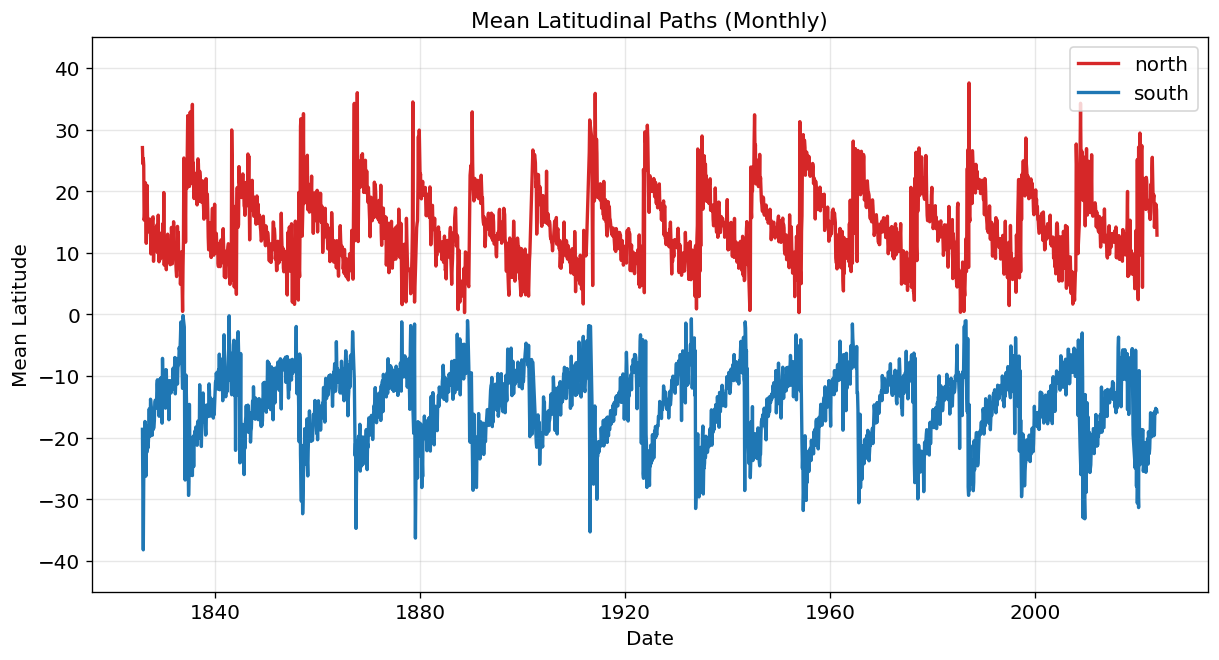

In [12]:
# Your code here: Calculate and plot mean latitudinal paths
df["year_as_months"] = df["date"].dt.to_period("M")

mean_lat = df.groupby(["year_as_months", "hemisphere"])["latitude"].mean().reset_index()
mean_lat["date"] = mean_lat["year_as_months"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6))

for hemi, g in mean_lat.groupby("hemisphere"):
    ax.plot(g["date"], g["latitude"],label=hemi,color=colors[hemi],linewidth=2)

ax.set_title("Mean Latitudinal Paths (Monthly)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude")
ax.legend()
ax.set_ylim(-45,45)
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Response using ChatGPT 5.4 Thinking Mode:*

Use prompts that make it teach, not just answer.

Best pattern:
“Teach me [topic] at my level. Start with intuition, then the math, then one concrete example. Keep it concise. After each section, give me 1 quick check question before moving on. Point out common mistakes.”

For your subjects, make it more specific:
“Teach me [machine learning / solar physics topic] like I’m a student who wants real understanding, not memorization.


*   Give the physical or intuitive idea first
*   Define the important terms
*  Show the core equations and what each term means
*   Walk through one worked example
*   Connect it to real data or observations
*   End with 3 practice questions

Good prompt templates:


For ML:
“Explain [topic] from intuition to derivation. Show why it works, when it fails, and one toy example. Then quiz me.”

Example:
“Teach me support vector machines. Start with the geometric intuition, then derive the margin idea, then explain slack variables and C in plain English. End with 3 short practice questions.”

For solar physics:
“Teach me [topic] from physical intuition to observational consequences. Explain what is happening physically, what variables matter, how we observe it, and what signatures appear in data.”

Example:
“Teach me the solar cycle and butterfly diagram. Explain the physical meaning, why sunspots migrate in latitude, what the plot shows, and what it tells us about the solar dynamo.”

Best extra instructions to add:
*   “Do not skip steps.”
*   “Assume I want conceptual understanding and mathematical clarity.”
*   “Use simple language first, then technical language.”
*   “Label algebra tricks briefly.”
*   “Ask me a question before giving the full answer if I should try first.”
*  “Compare this to related concepts so I do not confuse them.”


Really effective study flow:

*   “Explain it simply.”
*   “Now give me the math.”
*   “Now test me.”
*   “Now give me a harder variant.”
*   “Now connect it to a real dataset or figure.”


A very strong all-purpose prompt:

“Help me learn [topic] deeply. Start with intuition, then formal definition, then math, then one worked example, then one real-world interpretation. Keep each step short and clear. Do not skip derivation steps. Afterward, quiz me with 3 questions and check my answers like a tutor.”

For you, the biggest improvement is usually this:
ask it to be a tutor, not a solver. That means explanations, checkpoints, comparisons, and quizzes.

I can also give you a custom prompt template specifically for learning ML math and solar/space physics.

*Reflection:*


It was very interesting to see this extremely detailed response from just a simple 1 line prompt. It seems as though the AI is very aware of areas that it tends to not be very clear in (eg do not skip steps, or use simple language) and expects extra prompting in those regions. I will ensure that if I am using the AI to develop any form of understanding, to break the process down into steps/smaller chunks rather than ask for a large general overview, as it seems to work better with a pipeline of this form. I was also very suprised by the fact that it recommended to me to ask it to generate practice questions. This is likely because I have used it before to prepare for examinations- giving it topics/questions that I have solved for coursework, and asked it to generate conceptual problems so that I could get practice. It seems to have imbibed that knowledge into the responses it gives me. Overall, this has shown me how best to use AI as a tool for learning in general- as a way to gain an initial simple conceptual understanding, then to verify my understanding by using AI as my 'tutor.'